In [1]:
#importing required libraries
import numpy as np
import pandas as pd
import math
from math import log
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
#read the data set of backorder
backorder_data = pd.read_csv('Back_order_train.csv')

In [3]:
#Display first 5 rows of backorder data set
backorder_data.head()

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,No,No,No,Yes,No,No
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.99,0.99,0.0,No,No,No,Yes,No,No
2,1043696,2.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.10,0.13,0.0,No,No,No,Yes,No,No
4,1044048,8.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No


In [4]:
#Information about data type of columns
backorder_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1687861 entries, 0 to 1687860
Data columns (total 23 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   sku                1687861 non-null  object 
 1   national_inv       1687860 non-null  float64
 2   lead_time          1586967 non-null  float64
 3   in_transit_qty     1687860 non-null  float64
 4   forecast_3_month   1687860 non-null  float64
 5   forecast_6_month   1687860 non-null  float64
 6   forecast_9_month   1687860 non-null  float64
 7   sales_1_month      1687860 non-null  float64
 8   sales_3_month      1687860 non-null  float64
 9   sales_6_month      1687860 non-null  float64
 10  sales_9_month      1687860 non-null  float64
 11  min_bank           1687860 non-null  float64
 12  potential_issue    1687860 non-null  object 
 13  pieces_past_due    1687860 non-null  float64
 14  perf_6_month_avg   1687860 non-null  float64
 15  perf_12_month_avg  1687860 non-n

In [5]:
#Shape of backorder data set 
backorder_data.shape

(1687861, 23)

In [6]:
#Describes the backorder data set 
backorder_data.describe()

,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty
count,1.687860e+06,1.586967e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06
mean,4.961118e+02,7.872267e+00,4.405202e+01,1.781193e+02,3.449867e+02,5.063644e+02,5.592607e+01,1.750259e+02,3.417288e+02,5.252697e+02,5.277230e+01,2.043724e+00,-6.872059e+00,-6.437947e+00,6.264507e-01
std,2.961523e+04,7.056024e+00,1.342742e+03,5.026553e+03,9.795152e+03,1.437892e+04,1.928196e+03,5.192378e+03,9.613167e+03,1.483861e+04,1.254983e+03,2.360165e+02,2.655636e+01,2.584333e+01,3.372224e+01
min,-2.725600e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.900000e+01,-9.900000e+01,0.000000e+00
25%,4.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.300000e-01,6.600000e-01,0.000000e+00
50%,1.500000e+01,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,8.200000e-01,8.100000e-01,0.000000e+00
75%,8.000000e+01,9.000000e+00,0.000000e+00,4.000000e+00,1.200000e+01,2.000000e+01,4.000000e+00,1.500000e+01,3.100000e+01,4.700000e+01,3.000000e+00,0.000000e+00,9.700000e-01,9.500000e-01,0.000000e+00
max,1.233440e+07,5.200000e+01,4.894080e+05,1.427612e+06,2.461360e+06,3.777304e+06,7.417740e+05,1.105478e+06,2.146625e+06,3.205172e+06,3.133190e+05,1.464960e+05,1.000000e+00,1.000000e+00,1.253000e+04


In [7]:
# Displaying backorder data 
backorder_data

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,No,No,No,Yes,No,No
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.99,0.99,0.0,No,No,No,Yes,No,No
2,1043696,2.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.10,0.13,0.0,No,No,No,Yes,No,No
4,1044048,8.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1687856,1373987,-1.0,NaN,0.0,5.0,7.0,9.0,1.0,3.0,3.0,...,0.0,-99.00,-99.00,1.0,No,No,No,Yes,No,No
1687857,1524346,-1.0,9.0,0.0,7.0,9.0,11.0,0.0,8.0,11.0,...,0.0,0.86,0.84,1.0,Yes,No,No,No,No,Yes
1687858,1439563,62.0,9.0,16.0,39.0,87.0,126.0,35.0,63.0,153.0,...,0.0,0.86,0.84,6.0,No,No,No,Yes,No,No
1687859,1502009,19.0,4.0,0.0,0.0,0.0,0.0,2.0,7.0,12.0,...,0.0,0.73,0.78,1.0,No,No,No,Yes,No,No


In [8]:
#To remove last row that has all the null values 
backorder_data = backorder_data.dropna(thresh = 2 ,how = 'all')

In [9]:
#Checking whether the data set of back order has null values
backorder_data.isnull().sum()

sku                       0
national_inv              0
lead_time            100893
in_transit_qty            0
forecast_3_month          0
forecast_6_month          0
forecast_9_month          0
sales_1_month             0
sales_3_month             0
sales_6_month             0
sales_9_month             0
min_bank                  0
potential_issue           0
pieces_past_due           0
perf_6_month_avg          0
perf_12_month_avg         0
local_bo_qty              0
deck_risk                 0
oe_constraint             0
ppap_risk                 0
stop_auto_buy             0
rev_stop                  0
went_on_backorder         0
dtype: int64

In [10]:
#Replacing yes/no with 1/0 for potential_issue,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
object_cols = ['potential_issue','deck_risk','oe_constraint','ppap_risk','stop_auto_buy','rev_stop', 'went_on_backorder']

for col in object_cols:
    backorder_data[col]=backorder_data[col].map(dict(Yes=1, No=0))

backorder_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1687860 entries, 0 to 1687859
Data columns (total 23 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   sku                1687860 non-null  object 
 1   national_inv       1687860 non-null  float64
 2   lead_time          1586967 non-null  float64
 3   in_transit_qty     1687860 non-null  float64
 4   forecast_3_month   1687860 non-null  float64
 5   forecast_6_month   1687860 non-null  float64
 6   forecast_9_month   1687860 non-null  float64
 7   sales_1_month      1687860 non-null  float64
 8   sales_3_month      1687860 non-null  float64
 9   sales_6_month      1687860 non-null  float64
 10  sales_9_month      1687860 non-null  float64
 11  min_bank           1687860 non-null  float64
 12  potential_issue    1687860 non-null  int64  
 13  pieces_past_due    1687860 non-null  float64
 14  perf_6_month_avg   1687860 non-null  float64
 15  perf_12_month_avg  1687860 non-n

In [11]:
backorder_data

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,0,0,0,1,0,0
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.99,0.99,0.0,0,0,0,1,0,0
2,1043696,2.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,1,0,0,1,0,0
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.10,0.13,0.0,0,0,0,1,0,0
4,1044048,8.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1687855,1407754,0.0,2.0,0.0,10.0,10.0,10.0,0.0,5.0,7.0,...,0.0,0.69,0.69,5.0,1,0,0,1,0,0
1687856,1373987,-1.0,NaN,0.0,5.0,7.0,9.0,1.0,3.0,3.0,...,0.0,-99.00,-99.00,1.0,0,0,0,1,0,0
1687857,1524346,-1.0,9.0,0.0,7.0,9.0,11.0,0.0,8.0,11.0,...,0.0,0.86,0.84,1.0,1,0,0,0,0,1
1687858,1439563,62.0,9.0,16.0,39.0,87.0,126.0,35.0,63.0,153.0,...,0.0,0.86,0.84,6.0,0,0,0,1,0,0


In [12]:
backorder_data['perf_6_month_avg']=backorder_data['perf_6_month_avg'].replace(-99,np.NaN)
backorder_data['perf_12_month_avg']=backorder_data['perf_12_month_avg'].replace(-99,np.NaN)

In [13]:
backorder_data.isnull().sum()

sku                       0
national_inv              0
lead_time            100893
in_transit_qty            0
forecast_3_month          0
forecast_6_month          0
forecast_9_month          0
sales_1_month             0
sales_3_month             0
sales_6_month             0
sales_9_month             0
min_bank                  0
potential_issue           0
pieces_past_due           0
perf_6_month_avg     129478
perf_12_month_avg    122050
local_bo_qty              0
deck_risk                 0
oe_constraint             0
ppap_risk                 0
stop_auto_buy             0
rev_stop                  0
went_on_backorder         0
dtype: int64

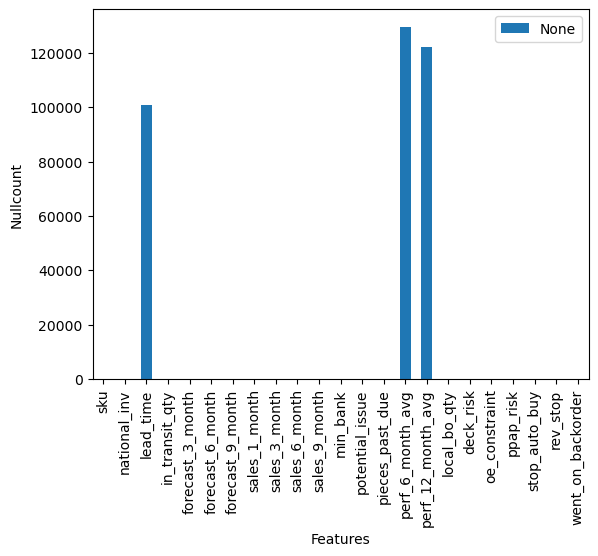

In [14]:
null = backorder_data.isnull().sum()
null.plot(kind='bar',xlabel="Features",ylabel="Nullcount")
plt.legend(bbox_to_anchor=(1.0, 1.0))
plt.show()

In [15]:
#Replacing missing values -- Nan values with 0 and then replacing it with median
for feature in backorder_data.columns:
    backorder_data[feature].fillna(value=backorder_data[feature].median(),inplace=True)
    #backorder_data[feature].replace(NaN,backorder_data[feature].median(),inplace=True)

In [16]:
backorder_data

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.85,0.83,0.0,0,0,0,1,0,0
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.99,0.99,0.0,0,0,0,1,0,0
2,1043696,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.85,0.83,0.0,1,0,0,1,0,0
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.10,0.13,0.0,0,0,0,1,0,0
4,1044048,8.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.85,0.83,0.0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1687855,1407754,0.0,2.0,0.0,10.0,10.0,10.0,0.0,5.0,7.0,...,0.0,0.69,0.69,5.0,1,0,0,1,0,0
1687856,1373987,-1.0,8.0,0.0,5.0,7.0,9.0,1.0,3.0,3.0,...,0.0,0.85,0.83,1.0,0,0,0,1,0,0
1687857,1524346,-1.0,9.0,0.0,7.0,9.0,11.0,0.0,8.0,11.0,...,0.0,0.86,0.84,1.0,1,0,0,0,0,1
1687858,1439563,62.0,9.0,16.0,39.0,87.0,126.0,35.0,63.0,153.0,...,0.0,0.86,0.84,6.0,0,0,0,1,0,0


In [17]:
backorder_data.isnull().sum()

sku                  0
national_inv         0
lead_time            0
in_transit_qty       0
forecast_3_month     0
forecast_6_month     0
forecast_9_month     0
sales_1_month        0
sales_3_month        0
sales_6_month        0
sales_9_month        0
min_bank             0
potential_issue      0
pieces_past_due      0
perf_6_month_avg     0
perf_12_month_avg    0
local_bo_qty         0
deck_risk            0
oe_constraint        0
ppap_risk            0
stop_auto_buy        0
rev_stop             0
went_on_backorder    0
dtype: int64

In [18]:
backorder_data= backorder_data.drop_duplicates()
backorder_data

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.85,0.83,0.0,0,0,0,1,0,0
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.99,0.99,0.0,0,0,0,1,0,0
2,1043696,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.85,0.83,0.0,1,0,0,1,0,0
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.10,0.13,0.0,0,0,0,1,0,0
4,1044048,8.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.85,0.83,0.0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1687855,1407754,0.0,2.0,0.0,10.0,10.0,10.0,0.0,5.0,7.0,...,0.0,0.69,0.69,5.0,1,0,0,1,0,0
1687856,1373987,-1.0,8.0,0.0,5.0,7.0,9.0,1.0,3.0,3.0,...,0.0,0.85,0.83,1.0,0,0,0,1,0,0
1687857,1524346,-1.0,9.0,0.0,7.0,9.0,11.0,0.0,8.0,11.0,...,0.0,0.86,0.84,1.0,1,0,0,0,0,1
1687858,1439563,62.0,9.0,16.0,39.0,87.0,126.0,35.0,63.0,153.0,...,0.0,0.86,0.84,6.0,0,0,0,1,0,0


In [19]:
backorder_data = backorder_data.drop(['sku'],axis=1)

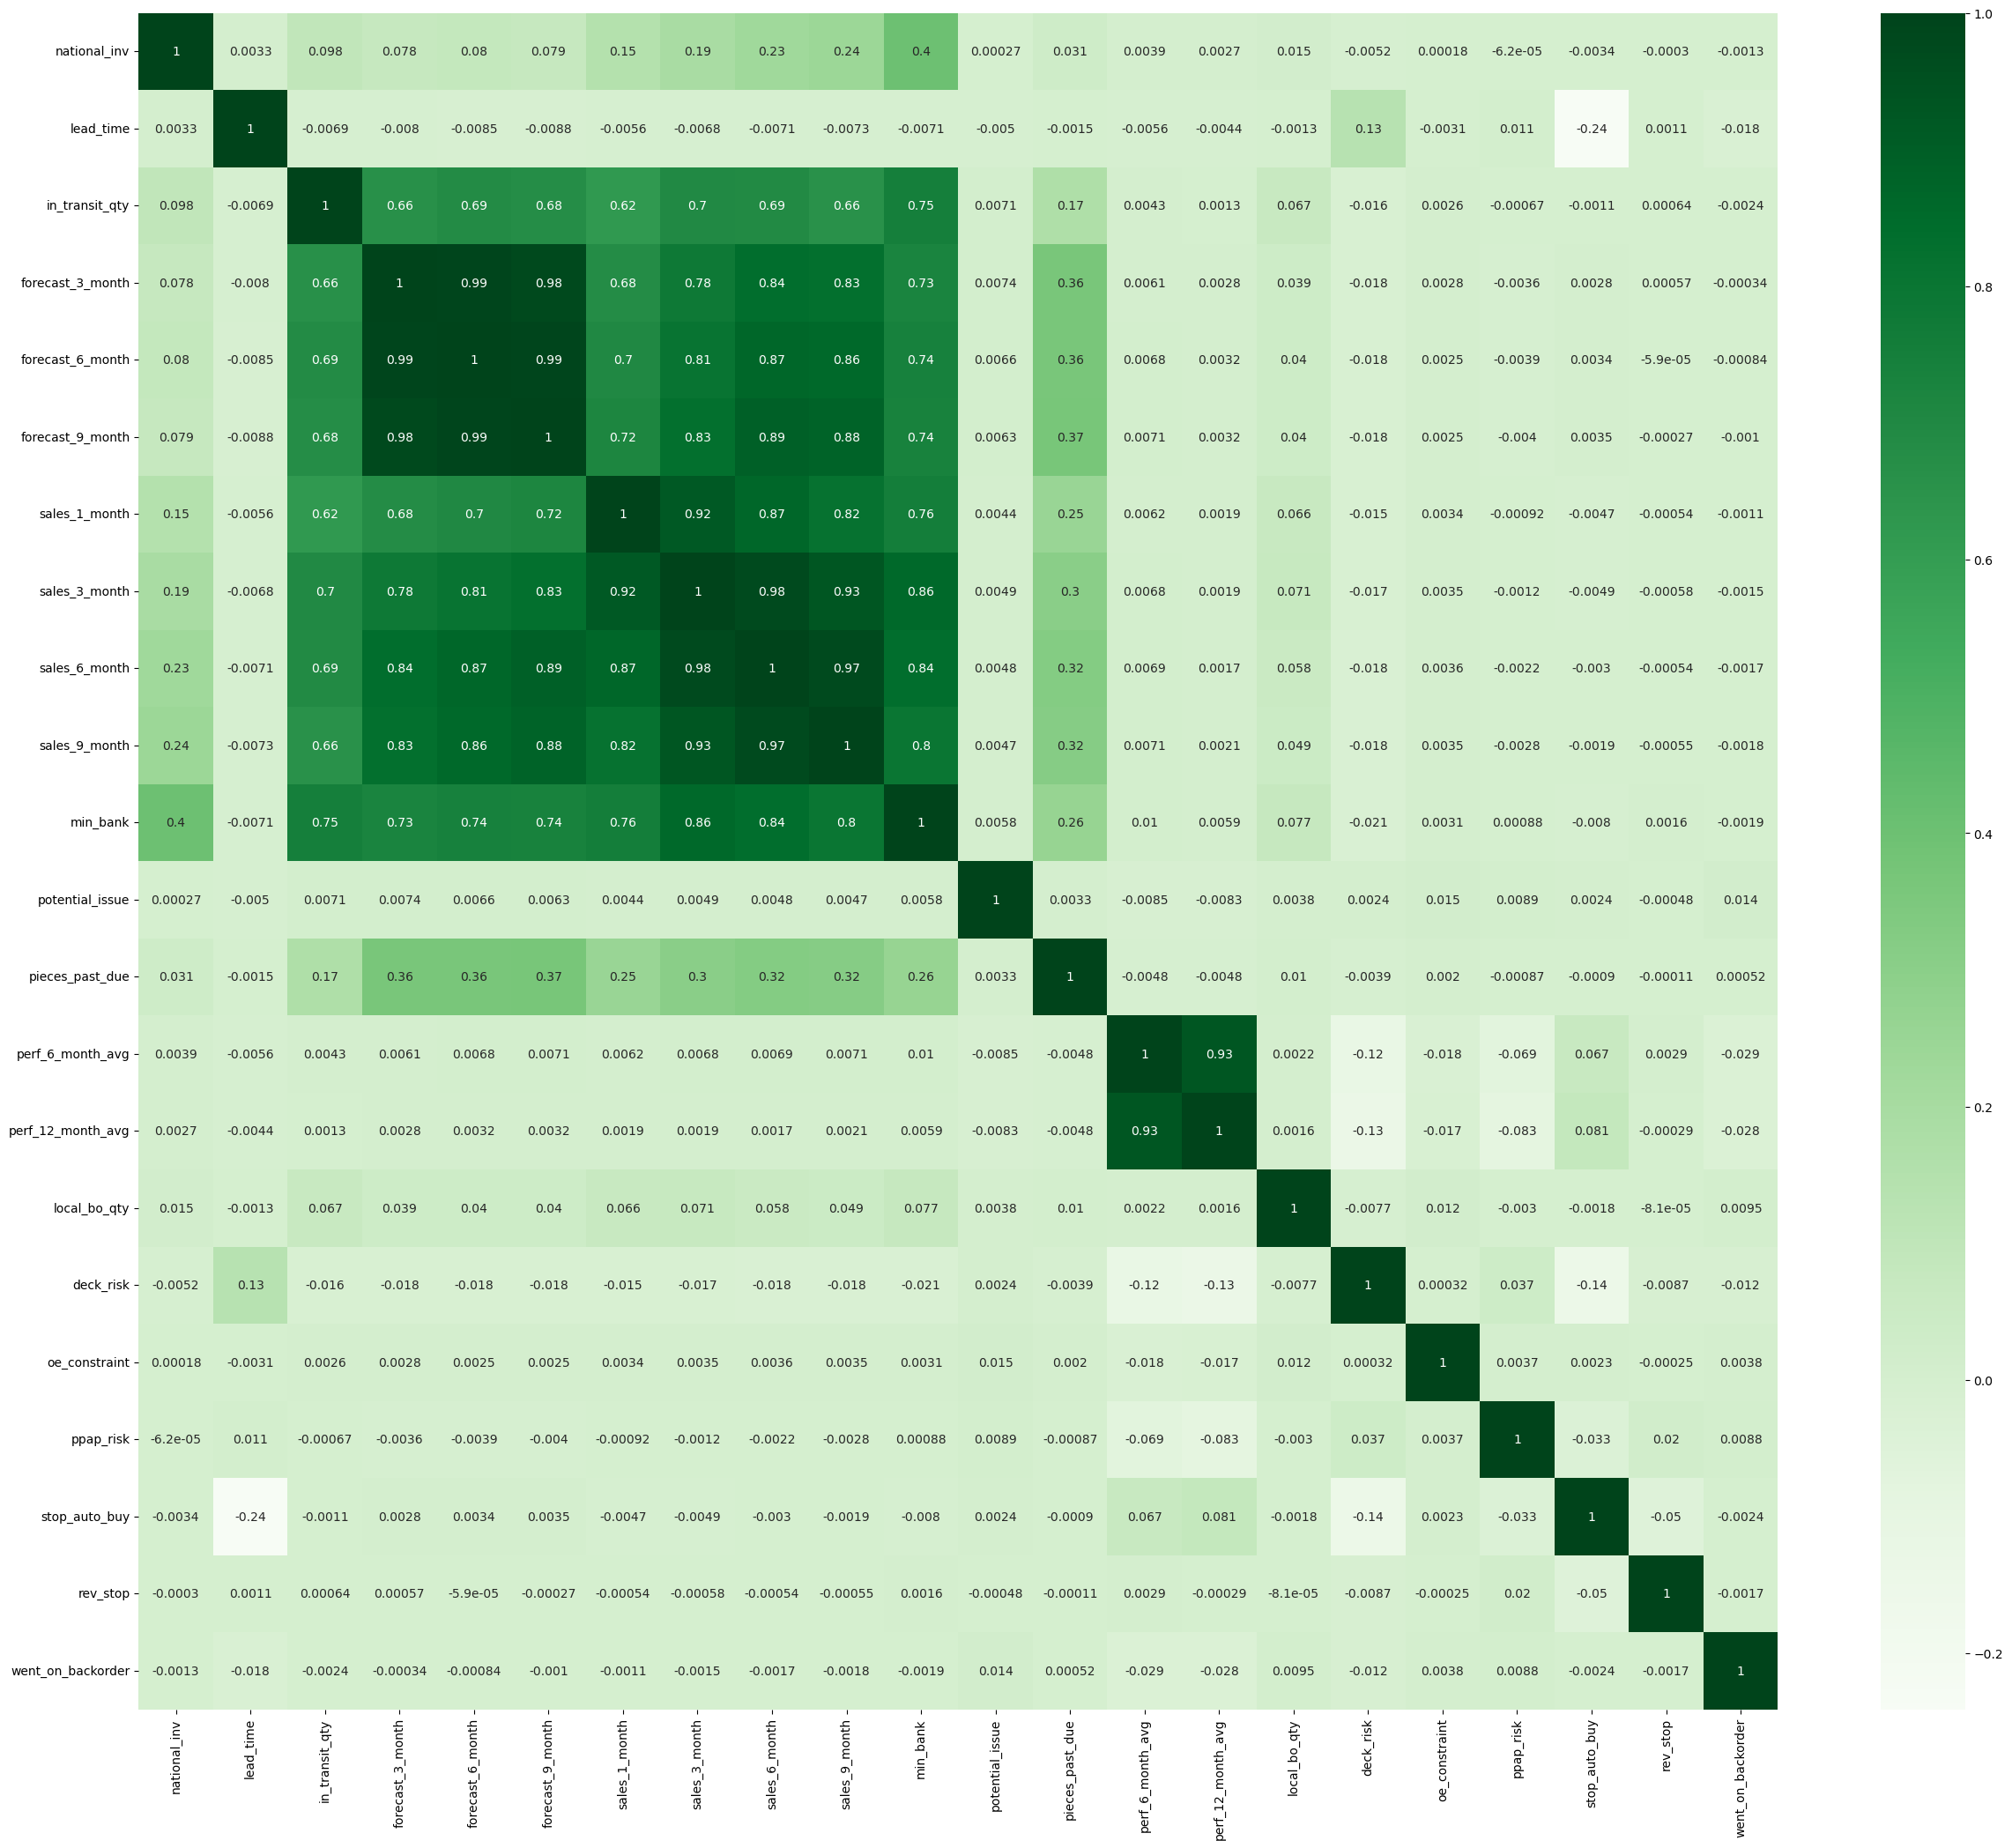

In [20]:
#Correlation between features
backorder_correlation = backorder_data.corr()
plt.figure(figsize=(30,25))
sns.heatmap(backorder_correlation, cmap="Greens",annot=True)
plt.show()

In [21]:
backorder_correlation

,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
national_inv,1.000000,0.003321,0.098238,0.078199,0.079744,0.078948,0.147449,0.192605,0.225067,0.239613,...,0.030677,0.003929,0.002697,0.014887,-0.005156,0.000185,-0.000062,-0.003380,-0.000305,-0.001315
lead_time,0.003321,1.000000,-0.006863,-0.008045,-0.008548,-0.008773,-0.005618,-0.006769,-0.007117,-0.007261,...,-0.001510,-0.005622,-0.004414,-0.001259,0.134983,-0.003095,0.010739,-0.240950,0.001077,-0.018104
in_transit_qty,0.098238,-0.006863,1.000000,0.662648,0.687768,0.679152,0.619270,0.698417,0.689908,0.659372,...,0.167460,0.004300,0.001344,0.066612,-0.016188,0.002565,-0.000671,-0.001085,0.000644,-0.002427
forecast_3_month,0.078199,-0.008045,0.662648,1.000000,0.990490,0.977337,0.684494,0.781178,0.835585,0.825539,...,0.361214,0.006057,0.002815,0.039419,-0.017508,0.002798,-0.003625,0.002836,0.000574,-0.000340
forecast_6_month,0.079744,-0.008548,0.687768,0.990490,1.000000,0.994945,0.701770,0.808755,0.868099,0.858253,...,0.363147,0.006827,0.003187,0.039724,-0.017789,0.002473,-0.003864,0.003413,-0.000059,-0.000840
forecast_9_month,0.078948,-0.008773,0.679152,0.977337,0.994945,1.000000,0.716367,0.829911,0.891884,0.881894,...,0.366001,0.007113,0.003243,0.039732,-0.017939,0.002493,-0.003956,0.003536,-0.000274,-0.001030
sales_1_month,0.147449,-0.005618,0.619270,0.684494,0.701770,0.716367,1.000000,0.918548,0.867479,0.815959,...,0.249526,0.006216,0.001909,0.066188,-0.014748,0.003402,-0.000919,-0.004737,-0.000541,-0.001131
sales_3_month,0.192605,-0.006769,0.698417,0.781178,0.808755,0.829911,0.918548,1.000000,0.975594,0.929491,...,0.304565,0.006804,0.001913,0.071030,-0.017196,0.003500,-0.001229,-0.004920,-0.000576,-0.001512
sales_6_month,0.225067,-0.007117,0.689908,0.835585,0.868099,0.891884,0.867479,0.975594,1.000000,0.971833,...,0.323552,0.006859,0.001683,0.057765,-0.018170,0.003624,-0.002208,-0.002972,-0.000541,-0.001728
sales_9_month,0.239613,-0.007261,0.659372,0.825539,0.858253,0.881894,0.815959,0.929491,0.971833,1.000000,...,0.317692,0.007138,0.002067,0.048880,-0.018165,0.003477,-0.002783,-0.001894,-0.000547,-0.001764


In [22]:
"""figure, ax = plt.subplots(7,3,figsize=(30,30))
index = -1
ax = ax.flatten()
data = backorder_data.drop(['went_on_backorder'],axis=1)
for feature in data.columns:
    sns.distplot(data[feature],ax=ax[index])
    index = index + 1
plt.tight_layout(pad=0.5, w_pad=0.7, h_pad=5.0)
   # plt.xticks(rotation=90)
   # plt.show()"""

"figure, ax = plt.subplots(7,3,figsize=(30,30))\nindex = -1\nax = ax.flatten()\ndata = backorder_data.drop(['went_on_backorder'],axis=1)\nfor feature in data.columns:\n    sns.distplot(data[feature],ax=ax[index])\n    index = index + 1\nplt.tight_layout(pad=0.5, w_pad=0.7, h_pad=5.0)\n   # plt.xticks(rotation=90)\n   # plt.show()"

array([[<AxesSubplot:title={'center':'national_inv'}>,
        <AxesSubplot:title={'center':'lead_time'}>,
        <AxesSubplot:title={'center':'in_transit_qty'}>,
        <AxesSubplot:title={'center':'forecast_3_month'}>,
        <AxesSubplot:title={'center':'forecast_6_month'}>],
       [<AxesSubplot:title={'center':'forecast_9_month'}>,
        <AxesSubplot:title={'center':'sales_1_month'}>,
        <AxesSubplot:title={'center':'sales_3_month'}>,
        <AxesSubplot:title={'center':'sales_6_month'}>,
        <AxesSubplot:title={'center':'sales_9_month'}>],
       [<AxesSubplot:title={'center':'min_bank'}>,
        <AxesSubplot:title={'center':'potential_issue'}>,
        <AxesSubplot:title={'center':'pieces_past_due'}>,
        <AxesSubplot:title={'center':'perf_6_month_avg'}>,
        <AxesSubplot:title={'center':'perf_12_month_avg'}>],
       [<AxesSubplot:title={'center':'local_bo_qty'}>,
        <AxesSubplot:title={'center':'deck_risk'}>,
        <AxesSubplot:title={'center':'o

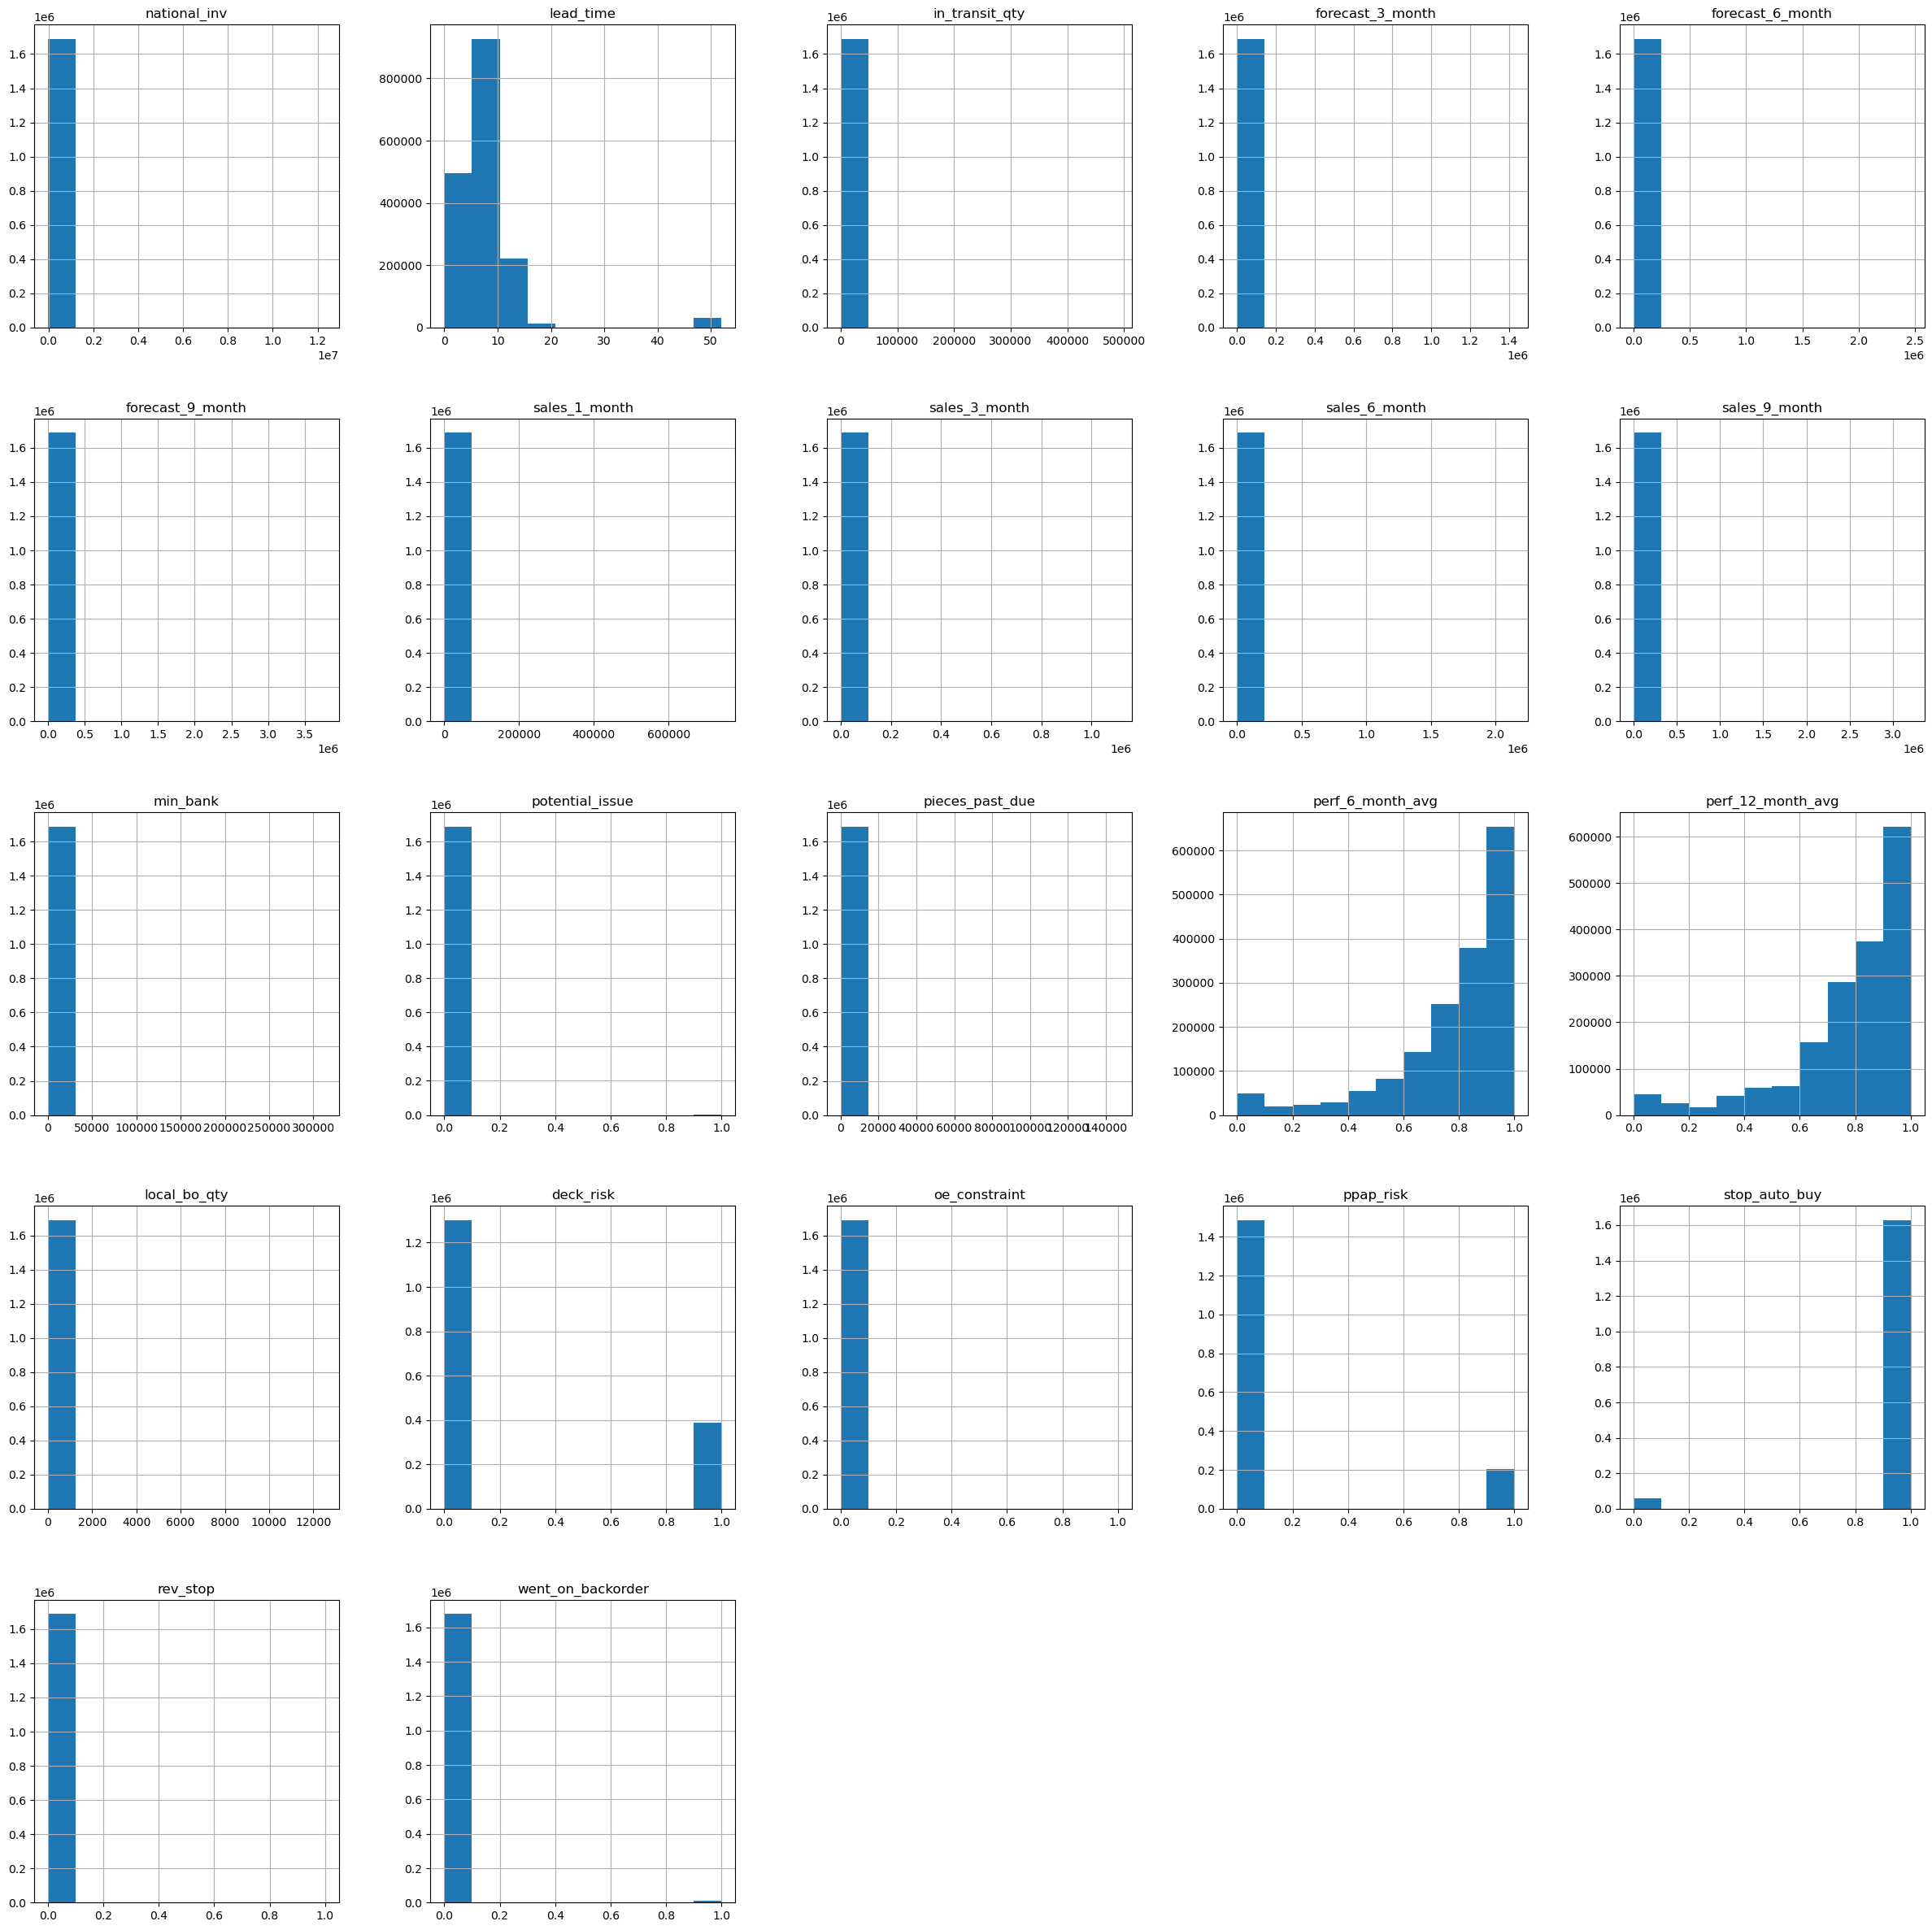

In [23]:
backorder_data.hist(figsize=(30,30))

In [24]:
#pair plot to show relationships between attributes of a dataset
#sns.pairplot(backorder_data,vars=backorder_data.columns,hue='went_on_backorder')

In [25]:
#forecast_sales = ['forecast_3_month','forecast_6_month','forecast_9_month','sales_1_month','sales_3_month','sales_6_month','sales_9_month']
#sns.pairplot(backorder_data,hue='went_on_backorder')
#sns.plt.show()

In [26]:
#Target and features 
y_target=backorder_data['went_on_backorder']
X_features=backorder_data.drop(['went_on_backorder'], axis=1)

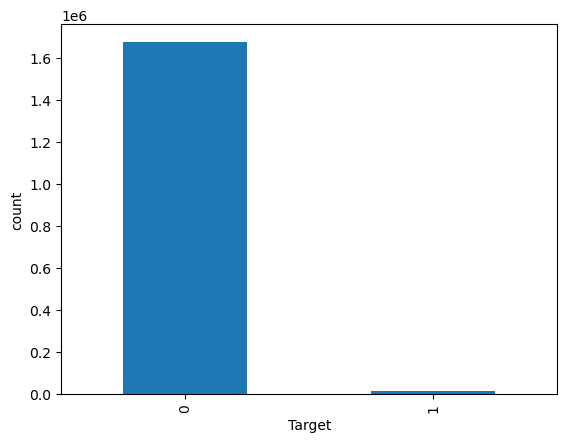

In [27]:
y_target.value_counts().plot(kind='bar',xlabel="Target",ylabel="count")
plt.show()

In [28]:
#Best feature selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
bestfeatures = SelectKBest(score_func=f_classif, k= 12)
fit = bestfeatures.fit(X_features,y_target)
fit.get_feature_names_out()

array(['lead_time', 'in_transit_qty', 'sales_9_month', 'min_bank',
       'potential_issue', 'perf_6_month_avg', 'perf_12_month_avg',
       'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk',
       'stop_auto_buy'], dtype=object)

In [29]:
X_features_red = backorder_data [['lead_time', 'in_transit_qty', 'min_bank', 'potential_issue',
       'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty',
       'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy',
       'rev_stop']]

In [30]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
scaled_feature=scaler.fit_transform(X_features_red)
X_scaled=scaled_feature

In [31]:
#Balancing imbalanced class data using SMOTE
#!pip install imblearn
from imblearn.over_sampling import SMOTE
x_res,y_res = SMOTE().fit_resample(X_scaled,y_target)
y_res.value_counts()

0    1676567
1    1676567
Name: went_on_backorder, dtype: int64

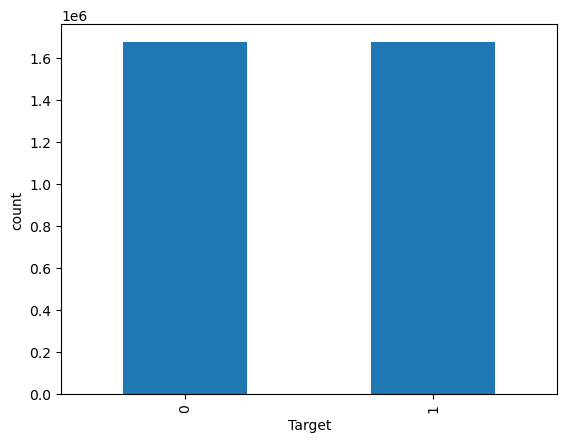

In [32]:
y_res.value_counts().plot(kind='bar',xlabel="Target",ylabel="count")
plt.show()

In [33]:
#Spliting data into training and test data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x_res,y_res,test_size=0.2,random_state=100)

In [34]:
from sklearn import linear_model 
lr_clf = linear_model.LogisticRegression(penalty='l2', C=1.0)
lr_clf.fit(X_train, y_train)
y_predict_lr = lr_clf.predict(X_test)
print("Training Accuracy of Logistic Regression:\n",lr_clf.score(X_train, y_train)*100)
print("Test Accuracy of Logistic Regression:\n",lr_clf.score(X_test,y_test)*100)

Training Accuracy of Logistic Regression:
 60.77881623421673
Test Accuracy of Logistic Regression:
 60.81592300936288


In [35]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)
y_predict_dt = dt_clf.predict(X_test)
print("Training Accuracy of Decision Tree :\n",dt_clf.score(X_train, y_train)*100)
print("Test Accuracy of Decision Tree :\n",dt_clf.score(X_test, y_test)*100)

Training Accuracy of Decision Tree :
 88.09855854989381
Test Accuracy of Decision Tree :
 87.75429560694693


In [36]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)
y_predict_rf = rf_clf.predict(X_test)
print("Training Accuracy of Random Forest:\n",rf_clf.score(X_train, y_train)*100)
print("Test Accuracy of Random Forest:\n",rf_clf.score(X_test, y_test)*100)

Training Accuracy of Random Forest:
 88.09855854989381
Test Accuracy of Random Forest:
 87.89371737195192


In [37]:
#from sklearn.ensemble import BaggingClassifier
#bg_clf = BaggingClassifier()
#bg_clf.fit(X_train, y_train)
#y_predict_bg = bg_clf.predict(X_test)
#print("Training Accuracy of Bagging Classifier:\n",bg_clf.score(X_train, y_train)*100)
#print("Test Accuracy of Bagging Classifier:\n",bg_clf.score(X_test, y_test)*100)

In [38]:
from sklearn.naive_bayes import GaussianNB
knn_clf = GaussianNB()
knn_clf.fit(X_train, y_train)
y_predict_knn = knn_clf.predict(X_test)
print("Training Accuracy of KNN (N=2):\n",knn_clf.score(X_train, y_train)*100)
print("Test Accuracy of KNN (N=2):\n",knn_clf.score(X_test, y_test)*100)

Training Accuracy of KNN (N=2):
 52.183610331678544
Test Accuracy of KNN (N=2):
 52.08081392487925


In [39]:
#from sklearn import svm
#svm_clf = svm.SVC(kernel='linear')
#svm_clf.fit(X_train, y_train)
#y_predict_rf = svm_clf.predict(X_test)
#print("Training Accuracy of Random Forest:\n",svm_clf.score(X_train, y_train))
#print("Test Accuracy of Random Forest:\n",svm_clf.score(X_test, y_test))

In [40]:
from sklearn.metrics import classification_report,confusion_matrix
#confusion_matrix_lr = confusion_matrix(y_test,y_predict_lr)
print('Confusion Matrix for Logistic Regression:\n ',confusion_matrix(y_test,y_predict_lr))
print('Classification Report for Logistic Regression:\n ',classification_report(y_test,y_predict_lr))

Confusion Matrix for Logistic Regression:
  [[213398 122584]
 [140195 194450]]
Classification Report for Logistic Regression:
                precision    recall  f1-score   support

           0       0.60      0.64      0.62    335982
           1       0.61      0.58      0.60    334645

    accuracy                           0.61    670627
   macro avg       0.61      0.61      0.61    670627
weighted avg       0.61      0.61      0.61    670627



In [41]:
#confusion_matrix_dt = confusion_matrix(y_test,y_predict_dt)
print('Confusion Matrix for Decision Tree:\n ',confusion_matrix(y_test,y_predict_dt))
print('Classification Report for Decision Tree:\n ',classification_report(y_test,y_predict_dt))

Confusion Matrix for Decision Tree:
  [[291521  44461]
 [ 37662 296983]]
Classification Report for Decision Tree:
                precision    recall  f1-score   support

           0       0.89      0.87      0.88    335982
           1       0.87      0.89      0.88    334645

    accuracy                           0.88    670627
   macro avg       0.88      0.88      0.88    670627
weighted avg       0.88      0.88      0.88    670627



In [42]:
#confusion_matrix_rf = confusion_matrix(y_test,y_predict_rf)
print('Confusion Matrix for Random Forest:\n ',confusion_matrix(y_test,y_predict_rf))
print('Classification Report for Random Forest:\n ',classification_report(y_test,y_predict_rf))

Confusion Matrix for Random Forest:
  [[292020  43962]
 [ 37226 297419]]
Classification Report for Random Forest:
                precision    recall  f1-score   support

           0       0.89      0.87      0.88    335982
           1       0.87      0.89      0.88    334645

    accuracy                           0.88    670627
   macro avg       0.88      0.88      0.88    670627
weighted avg       0.88      0.88      0.88    670627



In [43]:
#confusion_matrix_rf = confusion_matrix(y_test,y_predict_bg)
#print('Confusion Matrix for Bagging classifier:\n ',confusion_matrix(y_test,y_predict_bg))
#print('Classification Report for Bagging classifier:\n ',classification_report(y_test,y_predict_bg))

In [44]:
#confusion_matrix_ = confusion_matrix(y_test,y_predict_bg)
print('Confusion Matrix for KNN classifier:\n ',confusion_matrix(y_test,y_predict_knn))
print('Classification Report for KNN classifier:\n ',classification_report(y_test,y_predict_knn))

Confusion Matrix for KNN classifier:
  [[ 18614 317368]
 [  3991 330654]]
Classification Report for KNN classifier:
                precision    recall  f1-score   support

           0       0.82      0.06      0.10    335982
           1       0.51      0.99      0.67    334645

    accuracy                           0.52    670627
   macro avg       0.67      0.52      0.39    670627
weighted avg       0.67      0.52      0.39    670627



In [45]:
from sklearn.metrics import roc_auc_score
score = roc_auc_score(y_test,rf_clf.predict_proba(X_test)[:, 1])
print('ROC_AUC Score of Random Forest:\n',score*100)

ROC_AUC Score of Random Forest:
 96.30221119326136


In [46]:
score = roc_auc_score(y_test,dt_clf.predict_proba(X_test)[:, 1])
print('ROC_AUC Score of Decision Tree:\n',score*100)

ROC_AUC Score of Decision Tree:
 96.03084623938476


In [47]:
score = roc_auc_score(y_test,lr_clf.predict_proba(X_test)[:, 1])
print('ROC_AUC Score of Logistic Regression:\n',score*100)

ROC_AUC Score of Logistic Regression:
 66.22215453914119


In [48]:
#from sklearn.metrics import roc_auc_score, roc_curve
#score = roc_auc_score(y_test,bg_clf.predict_proba(X_test)[:, 1])
#print('ROC_AUC Score of Bagging Classifier:\n',score*100)


In [49]:
score = roc_auc_score(y_test,knn_clf.predict_proba(X_test)[:, 1])
print('ROC_AUC Score of KNN Classifier:\n',score*100)

ROC_AUC Score of KNN Classifier:
 62.38020203097913


<function matplotlib.pyplot.show(close=None, block=None)>

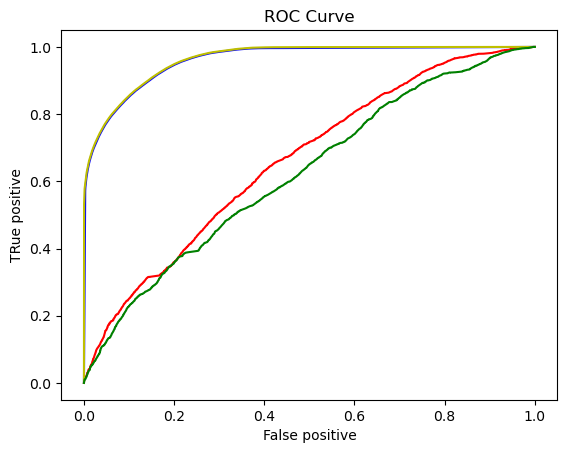

In [52]:
from sklearn.metrics import roc_curve
fpr_lr,tpr_lr,threshold = roc_curve(y_test,lr_clf.predict_proba(X_test)[:, 1])
fpr_dt,tpr_dt,threshold = roc_curve(y_test,dt_clf.predict_proba(X_test)[:, 1])
fpr_rf,tpr_rf,threshold = roc_curve(y_test,rf_clf.predict_proba(X_test)[:, 1])
fpr_knn,tpr_knn,threshold = roc_curve(y_test,knn_clf.predict_proba(X_test)[:, 1])

fpr = [fpr_lr, fpr_dt, fpr_rf, fpr_knn]
tpr = [tpr_lr, tpr_dt, tpr_rf, tpr_knn]

plt.title("ROC Curve")
plt.plot(fpr_lr,tpr_lr,'r',fpr_dt,tpr_dt,'b',fpr_rf,tpr_rf,'y',fpr_knn,tpr_knn,'g')
plt.ylabel("TRue positive")
plt.xlabel("False positive")
plt.show

In [ ]:
#from sklearn.metrics import precision_recall_fscore_support
#precision_recall_fscore_support(y_test,y_predict_lr)

In [ ]:
#from sklearn.metrics import precision_recall_fscore_support
#precision_recall_fscore_support(y_test,y_predict_lr, average = 'weighted')

In [53]:
from sklearn.metrics import precision_score,f1_score,recall_score
pr_score = precision_score(y_test,y_predict_lr,average='macro')
score_f1 = f1_score(y_test,y_predict_lr,average='macro')
score_recall = recall_score(y_test,y_predict_lr,average='macro')
print('Percision Score of Logistic Regression:\n',pr_score*100,'f1-score:',score_f1*100,'recall:',score_recall*100 )

Percision Score of Logistic Regression:
 60.8427117217094 f1-score: 60.78461747373698 recall: 60.81053180224628


In [54]:
#from sklearn.metrics import precision_score,f1_score,recall_score
pr_score = precision_score(y_test,y_predict_rf,average='macro')
score_f1 = f1_score(y_test,y_predict_rf,average='macro')
score_recall = recall_score(y_test,y_predict_rf,average='macro')
print('Percision Score of Random Forest:\n',pr_score*100,'f1-score:',score_f1*100,'recall:',score_recall*100 )

Percision Score of Random Forest:
 87.90793330020745 f1-score: 87.89293267214909 recall: 87.89567175616936


In [55]:
#from sklearn.metrics import precision_score,f1_score,recall_score
pr_score = precision_score(y_test,y_predict_dt,average='macro')
score_f1 = f1_score(y_test,y_predict_dt,average='macro')
score_recall = recall_score(y_test,y_predict_dt,average='macro')
print('Percision Score of Decision Tree:\n',pr_score*100,'f1-score:',score_f1*100,'recall:',score_recall*100 )

Percision Score of Decision Tree:
 87.76874283153724 f1-score: 87.75348323689656 recall: 87.75626816587877


In [56]:
#from sklearn.metrics import precision_score,f1_score,recall_score
#pr_score = precision_score(y_test,y_predict_bg,average='macro')
#score_f1 = f1_score(y_test,y_predict_bg,average='macro')
#score_recall = recall_score(y_test,y_predict_bg,average='macro')
#print('Percision Score of Bagging Classifier:\n',pr_score*100,'f1-score:',score_f1*100,'recall:',score_recall*100 )

In [57]:
from sklearn.metrics import precision_score,f1_score,recall_score
pr_score = precision_score(y_test,y_predict_knn,average='macro')
score_f1 = f1_score(y_test,y_predict_knn,average='macro')
score_recall = recall_score(y_test,y_predict_knn,average='macro')
print('Percision Score of KNN Classifier:\n',pr_score*100,'f1-score:',score_f1*100,'recall:',score_recall*100 )

Percision Score of KNN Classifier:
 66.6848667704967 f1-score: 38.83956168947411 recall: 52.17378532826045
